Mata Kuliah FSD

Kelas A

Anggota Kelompok :
1. Muhmmad Wahyu Ramadhani - 24523110
2. Handiva Rahmawan Diachmadja - 24523112

# Klasifikasi Menu Makanan Terlaris di Kantin Mawar
## Decision Tree vs Random Forest

## Tujuan
Memprediksi menu makanan paling laku di Kantin Mawar menggunakan:
- Decision Tree
- Random Forest

Dataset dibuat berdasarkan karakteristik menu makanan.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Dataset Penjualan Menu Makanan di Kantin Mawar

Fitur:
- harga (price)
- porsi (portion_size)
- rasa (taste_score)
- popularitas (popularity_score)

Label:
- jenis menu makanan

In [15]:
data = {
    'price': [15000,14000,13000,12000,16000,17000,18000,15000,
              15000,14000,13000,12000,16000,17000,18000,15000,
              15000,14000,13000,12000],

    'portion': [7,6,6,5,8,8,9,7,
                7,6,6,5,8,8,9,7,
                7,6,6,5],

    'taste': [9,8,7,7,9,9,8,9,
              9,8,7,7,9,9,8,9,
              9,8,7,7],

    'popularity': [10,9,8,7,9,9,8,10,
                   10,9,8,7,9,9,8,10,
                   10,9,8,7],

    'label': [
        'tahu_gimbal','ayam_remes','ketoprak','soto','nasi_goreng','nasi_prasmanan','nasi_kapau','ayam_bakar',
        'tahu_gimbal','ayam_remes','ketoprak','soto','nasi_goreng','nasi_prasmanan','nasi_kapau','ayam_bakar',
        'tahu_gimbal','ayam_remes','ketoprak','soto'
    ]
}

df = pd.DataFrame(data)
print(df.head())
print("\nJumlah data:", df.shape)

   price  portion  taste  popularity        label
0  15000        7      9          10  tahu_gimbal
1  14000        6      8           9   ayam_remes
2  13000        6      7           8     ketoprak
3  12000        5      7           7         soto
4  16000        8      9           9  nasi_goreng

Jumlah data: (20, 5)


## Preprocessing
- Pisahkan fitur & label
- Encoding
- Split data
- Normalisasi

In [16]:
X = df[['price','portion','taste','popularity']].values
y = df['label'].values

# Encoding
le = LabelEncoder()
y = le.fit_transform(y)

print("Mapping label:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=== SPLIT DATA ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nShape data:")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Mapping label:
ayam_bakar -> 0
ayam_remes -> 1
ketoprak -> 2
nasi_goreng -> 3
nasi_kapau -> 4
nasi_prasmanan -> 5
soto -> 6
tahu_gimbal -> 7
=== SPLIT DATA ===
X_train: (16, 4)
X_test : (4, 4)
y_train: (16,)
y_test : (4,)

Shape data:
Train: (16, 4)
Test : (4, 4)


## Decision Tree

In [17]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Akurasi Decision Tree:", acc_dt)

Akurasi Decision Tree: 0.0


## Random Forest

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Akurasi Random Forest:", acc_rf)

Akurasi Random Forest: 0.75


## EVALUASI

In [19]:
print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       2.0
           3       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       1.0

    accuracy                           0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           7       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.50      0.67      0.56         4
weighted avg       0.62      0.75      0.67         4



## VISUALISASI TREE

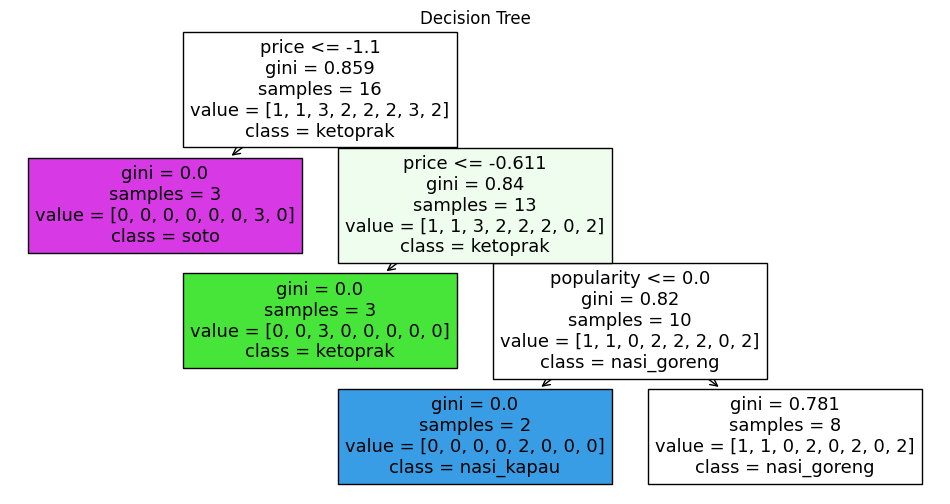

In [20]:
plt.figure(figsize=(12,6))
plot_tree(
    dt,
    feature_names=['price','portion','taste','popularity'],
    class_names=le.classes_,
    filled=True
)
plt.title("Decision Tree")
plt.show()

## PENGARUH n_estimators

In [21]:
n_list = [1,5,10,50,100]

for n in n_list:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"n_estimators={n} → accuracy={acc:.3f}")

n_estimators=1 → accuracy=0.750
n_estimators=5 → accuracy=0.750
n_estimators=10 → accuracy=0.750
n_estimators=50 → accuracy=0.750
n_estimators=100 → accuracy=0.750


## Analisis

### 1. Algoritma terbaik
Random Forest lebih baik karena lebih stabil dan akurat.

### 2. Kelebihan & Kekurangan
Decision Tree:
+ Mudah dipahami
- Overfitting

Random Forest:
+ Akurasi tinggi
- Lebih kompleks

### 3. Overfitting
Decision Tree bisa overfitting jika tidak dibatasi.

### 4. Pengaruh fitur
Fitur seperti taste dan popularity sangat berpengaruh terhadap menu terlaris.

---

## Jawaban

1. Decision Tree = 1 pohon, Random Forest = banyak pohon  
2. Decision Tree overfitting, RF mengatasinya dengan banyak pohon  
3. Bagging → data acak, fitur acak → variasi  
4. Decision Tree cocok untuk data kecil & interpretasi